## Análise de perguntas frequentes

In [1]:
import os
import torch
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np
import seaborn as sns
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer, util
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA


pd.set_option('display.max_colwidth', None)

DATA_PATH_EXTRACTED = '../topic_analysis_gravidez_results_two_steps_api/retained_questions_with_topics.csv'
DATA_PATH_ORIGINALS = '../data/cleaned/cleaned_comments_info.csv'
DATA_PATH_GOLD = '../CrawlerYTGabriel/files/queries.txt'
OUTPUT_PATH_FIGS = '../data/figs/'
OUTPUT_PATH_EMBEDDINGS = '../data/cleaned/embeddings/'
OUTPUT_PATH_SAMPLES = '../data/cleaned/sim_samples.csv'

MODEL_ID = 'google/embeddinggemma-300m'
MODEL_NAME = MODEL_ID.split('/')[-1]
EMBEDDING_TASK = 'sentence_similarity'
EMBEDDING_DATASET = 'retained_questions'

LIMIAR_POS = 0.80
LIMIAR_NEG = 0.50

# cria pasta para salvar embeddings caso não exista
os.makedirs(OUTPUT_PATH_EMBEDDINGS, exist_ok=True)

### Carregamento e preparação dos dados

In [2]:
gold_questions = []

with open(DATA_PATH_GOLD, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()

        if line:
            gold_questions.append(line)

print(gold_questions)

['Como ter certeza que estou grávida?', 'Quando devo começar as visitas ao pré-natal?', 'Onde posso fazer o pré-natal?', 'Quantas consultas de pré-natal será bom para mim e para meu bebê?', 'O que devo fazer se eu me sentir mal antes da data da próxima consulta?', 'Quanto tempo dura a gravidez?', 'O que é parto prematuro?', 'Como vou contar o tempo de gravidez: meses ou semanas?', 'A gravidez pode durar mais do que 9 meses?', 'O que é data provável para o parto?', 'Ter infecção de urina aumenta a chance de parto prematuro?', 'Posso tomar os remédios que já tenho costume de usar quando sinto dor?', 'O que posso fazer para evitar o parto prematuro?', 'Estou sentindo contrações antes do nono mês. É normal?', 'A partir de quando posso saber o sexo do bebê durante a gravidez?', 'Tem como saber o peso do bebê dentro do útero?', 'A partir de quando o embrião aparece dentro do meu útero?', 'A partir de quando o feto se forma?', 'A partir de quando o bebê começa a mexer dentro do útero?', 'Quan

In [3]:
# Perguntas extraídas
df_extracted = (
    pd.read_csv(DATA_PATH_EXTRACTED)
    .dropna(subset=['perguntas'])
    .copy()
)

extracted_comment_ids = df_extracted['comment_id'].tolist()
extracted_questions = df_extracted['perguntas'].astype(str).tolist()
extracted_topics = df_extracted['topic_id'].astype(str).tolist()
extracted_topic_names = df_extracted['Name'].fillna('Sem tópico').tolist()

df_extracted.shape, len(extracted_questions)

((11673, 14), 11673)

In [4]:
# Comentários originais
df_originals = (
    pd.read_csv(DATA_PATH_ORIGINALS)
    .loc[lambda df: df['comment_id'].isin(extracted_comment_ids), ['comment_id', 'comment']]
    .drop_duplicates('comment_id')
    .copy()
)
original_comment_ids = df_originals['comment_id'].tolist()
original_comments = df_originals['comment'].astype(str).tolist()

In [5]:
assert set(original_comment_ids) == set(extracted_comment_ids), 'Há perguntas sem comentário de origem'
assert df_originals['comment'].notna().all(), 'Há comentários nulos'

print(f'{len(extracted_questions):,} perguntas extraídas')
print(f'{len(original_comments):,} comentários originais únicos')
print(f'{len(gold_questions):,} perguntas padrão-ouro')

11,673 perguntas extraídas
9,896 comentários originais únicos
98 perguntas padrão-ouro


### Cálculo dos embeddings

In [6]:
cache_prefix = f'{MODEL_NAME}_{EMBEDDING_TASK}_{EMBEDDING_DATASET}'
path_gold = os.path.join(OUTPUT_PATH_EMBEDDINGS, f'{cache_prefix}_gold.pt')
path_extracted = os.path.join(OUTPUT_PATH_EMBEDDINGS, f'{cache_prefix}_extracted.pt')
path_originals = os.path.join(OUTPUT_PATH_EMBEDDINGS, f'{cache_prefix}_originals.pt')

MODEL = None

def get_embeddings(texts, cache_path, batch_size=16):
    """Carrega os embeddings existentes ou calcula e salva novos."""
    global MODEL

    if os.path.exists(cache_path):
        return torch.load(cache_path, map_location='cpu')

    if MODEL is None:
        MODEL = SentenceTransformer(MODEL_ID)

    embeddings = MODEL.encode(
        [f'task: sentence similarity | query: {text}' for text in texts],
        batch_size=batch_size,
        convert_to_tensor=True,
        normalize_embeddings=True,
    ).cpu()
    torch.save(embeddings, cache_path)
    return embeddings

embeddings_gold = get_embeddings(gold_questions, path_gold)
embeddings_extracted = get_embeddings(extracted_questions, path_extracted)
embeddings_originals = get_embeddings(original_comments, path_originals)

assert len(embeddings_gold) == len(gold_questions)
assert len(embeddings_extracted) == len(extracted_questions)
assert len(embeddings_originals) == len(original_comments)

### Cálculo de similaridade

In [7]:
# Cada linha representa uma pergunta padrão-ouro e cada coluna uma pergunta extraída.
similaridades = util.cos_sim(embeddings_gold.float(), embeddings_extracted.float())

In [8]:
embeddings_gold.shape, embeddings_extracted.shape, embeddings_originals.shape, similaridades.shape

(torch.Size([98, 768]),
 torch.Size([11673, 768]),
 torch.Size([9896, 768]),
 torch.Size([98, 11673]))

In [9]:
results_high_sim = []
thresholds = np.arange(0.50, 1.01, 0.1)

for threshold in thresholds:
    # Para cada pergunta extraída, verifica se alguma padrão-ouro passa do limiar.
    questions_above_threshold = (similaridades >= threshold).any(dim=0)

    results_high_sim.append({
        'threshold': threshold,
        'num_questions': questions_above_threshold.sum().item(),
        'pct_questions': questions_above_threshold.float().mean().item() * 100
    })

results_high_sim_df = pd.DataFrame(results_high_sim)
results_high_sim_df

,threshold,num_questions,pct_questions
0,0.5,11664,99.922901
1,0.6,11347,97.207230
2,0.7,7845,67.206371
3,0.8,1536,13.158572
4,0.9,76,0.651075
5,1.0,0,0.000000


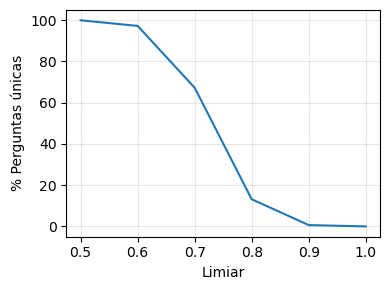

In [10]:
plt.figure(figsize=(4, 3))

plt.plot(
    results_high_sim_df['threshold'],
    results_high_sim_df['pct_questions'],
)

plt.xlabel('Limiar')
plt.ylabel('% Perguntas únicas')
plt.xticks(results_high_sim_df['threshold'])
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH_FIGS, f'{cache_prefix}_pct_questions_vs_threshold.png'))
plt.show()

In [11]:
results_high_sim = []

for i, gold_question in enumerate(gold_questions):
    # Similaridades da pergunta padrão-ouro com todas as perguntas extraídas.
    scores = similaridades[i]
    indices = scores.argsort(descending=True)

    # pega o número de perguntas que passam do limiar
    num_extracted = (scores >= LIMIAR_POS).sum().item()
    results_high_sim.append({
        'pergunta': gold_question,
        'num_perguntas': num_extracted,
        'perguntas': [extracted_questions[idx] for idx in indices[:num_extracted].tolist()],
        'similaridades': [scores[idx].item() for idx in indices[:num_extracted].tolist()]
    })

df_results_high = pd.DataFrame(results_high_sim).sort_values(by='num_perguntas', ascending=False).reset_index(drop=True)
df_results_high[['pergunta', 'num_perguntas']].head()

,pergunta,num_perguntas
0,"Já tive uma cesárea, posso ter parto normal na próxima gestação?",187
1,Como ter certeza que estou grávida?,147
2,Como posso ter alívio da dor durante o parto?,126
3,A gravidez pode durar mais do que 9 meses?,114
4,Como vou contar o tempo de gravidez: meses ou semanas?,105


In [12]:
df_results_high[['pergunta', 'num_perguntas']].tail()

,pergunta,num_perguntas
93,É proibido fazer exame de prevenção do câncer do útero na gravidez?,0
94,Posso beber nos finais de semana?,0
95,Quando devo começar as visitas ao pré-natal?,0
96,Tenho sentido dores na barriga e intestino preso,0
97,É normal ficar com menos vontade de fazer sexo?,0


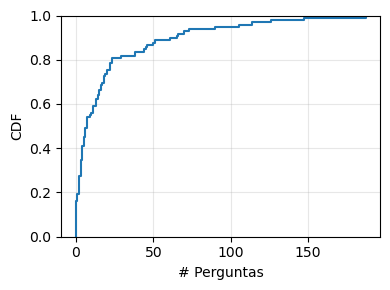

In [13]:
plt.figure(figsize=(4, 3))
sns.ecdfplot(
    data=df_results_high,
    x='num_perguntas'
)
plt.xlabel('# Perguntas')
plt.ylabel('CDF')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH_FIGS, f'{cache_prefix}_cdf_num_questions.png'))
plt.show()

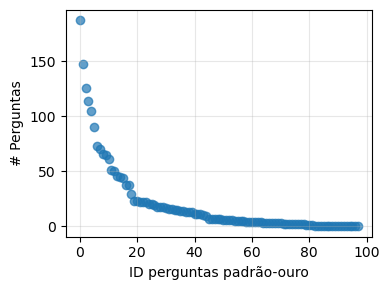

In [14]:
df_gold_counts = (
    df_results_high
    .sort_values('num_perguntas', ascending=False)
    .reset_index(drop=True)
)

plt.figure(figsize=(4, 3))

plt.scatter(
    x=df_gold_counts.index,
    y=df_gold_counts['num_perguntas'],
    alpha=0.7,
)

plt.xlabel('ID perguntas padrão-ouro')
plt.ylabel('# Perguntas')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH_FIGS, f'{cache_prefix}_num_questions_vs_gold_questions.png'))
plt.show()

In [15]:
df_results_high[df_results_high['num_perguntas'] == 0].shape, df_results_high[df_results_high['num_perguntas'] != 0].shape

((16, 4), (82, 4))

In [16]:
df_results_high = df_results_high.explode(['perguntas', 'similaridades']).reset_index(drop=True)
df_results_high = df_results_high[df_results_high['num_perguntas'] > 0]
df_results_high.shape

(2011, 4)

In [17]:
df_results_high.sample(5)

,pergunta,num_perguntas,perguntas,similaridades
1363,"Como preparar o seio para a amamentação, durante a gravidez?",38,Como fazer o bebê pegar a pega correta na amamentação?,0.811508
526,A gravidez pode durar mais do que 9 meses?,114,Com quantos meses de gravidez você está?,0.818179
1449,O que é data provável para o parto?,23,O parto dessa gestação será normal?,0.827692
322,Como ter certeza que estou grávida?,147,Como foi a gestação dessa gravidez?,0.804874
1383,Preciso de corte na vagina para o meu bebe nascer?,38,O corte feito no parto pode se tornar um problema na relação sexual depois?,0.839589


In [18]:
df_sample = df_results_high[['pergunta', 'perguntas', 'similaridades']].sample(100, random_state=42)
df_sample.to_csv(OUTPUT_PATH_SAMPLES, index=False)

### Perguntas distantes

In [19]:
max_similaridades_ext, indices_gold_ext = similaridades.max(dim=0)
max_similaridades_gold, indices_ext_gold = similaridades.max(dim=1)

df_ext_irrelev = pd.DataFrame({
    "pergunta": extracted_questions,
    "padrao_ouro_mais_proxima": [
        gold_questions[i] for i in indices_gold_ext.cpu().tolist()
    ],
    "max_similaridade": max_similaridades_ext.cpu().tolist(),
})

df_ext_irrelev = (
    df_ext_irrelev[
        df_ext_irrelev["max_similaridade"] < LIMIAR_NEG
    ]
    .sort_values("max_similaridade")
    .reset_index(drop=True)
)

df_gold_irrelev = pd.DataFrame({
    "pergunta_padrao_ouro": gold_questions,
    "pergunta_extraida_mais_proxima": [
        extracted_questions[i] for i in indices_ext_gold.cpu().tolist()
    ],
    "max_similaridade": max_similaridades_gold.cpu().tolist(),
})

df_gold_irrelev = (
    df_gold_irrelev[
        df_gold_irrelev["max_similaridade"] < LIMIAR_POS
    ]
    .sort_values("max_similaridade")
    .reset_index(drop=True)
)

In [20]:
df_gold_irrelev.head()

,pergunta_padrao_ouro,pergunta_extraida_mais_proxima,max_similaridade
0,Posso beber nos finais de semana?,Gestantes podem tomar refrigerante uma vez por semana?,0.699429
1,O que devo fazer se eu me sentir mal antes da data da próxima consulta?,O que devo fazer diante desses sintomas na gestação?,0.727913
2,Minha gengiva está sangrando quando escovo os dentes. O que fazer?,O que devo fazer se estiver saindo da minha região íntima algo branco com aparência de sangramento arterial?,0.732009
3,Quando devo tomar sol nos seios?,"Para recém-nascidos, ainda é recomendado banho de sol ou agora é preferível fazer passeios no final da tarde e de manhã?",0.739270
4,Posso tomar os remédios que já tenho costume de usar quando sinto dor?,"Posso tomar hoje as duas pílulas, a de ontem e a de hoje, no horário das 17h35?",0.744123


In [21]:
df_ext_irrelev.head()

,pergunta,padrao_ouro_mais_proxima,max_similaridade
0,Quem é MEI precisa seguir o mesmo processo de pagamento da guia exigido para quem não trabalha?,"Se eu não tiver força pra empurrar o bebe, será que alguém empurra minha barriga?",0.439055
1,"Por que o benefício foi fixado no salário mínimo vigente de R$ 1.302, se esse não é o valor atual?",O que é Teste do Pezinho?,0.451827
2,"Qual guia do INSS devo pagar: a contribuição facultativa mensal com salário de R$ 2.000 e parcela de R$ 400, a contribuição facultativa de 11% com salário de R$ 1.518 e parcela de R$ 300, ou a guia de baixa renda com salário de R$ 1.518 e parcela de R$ 75,90?",Quantas consultas de pré-natal será bom para mim e para meu bebê?,0.474634
3,O código 1473 de contribuinte facultativo serve para quem recebe Bolsa Família?,Preciso levar o cartão de pré-natal no dia do parto?,0.482578
4,"Por que está havendo desconto de R$ 300 por mês, totalizando R$ 1.200?",Posso beber nos finais de semana?,0.485026


### Visualização dos dados

In [22]:
gold = F.normalize(
    embeddings_gold.float(),
    p=2,
    dim=1
).cpu().numpy()

extracted = F.normalize(
    embeddings_extracted.float(),
    p=2,
    dim=1
).cpu().numpy()

originals = F.normalize(
    embeddings_originals.float(),
    p=2,
    dim=1
).cpu().numpy()

X = np.vstack([gold, extracted, originals])

In [23]:
pca = PCA(n_components=50)
X_pca = pca.fit_transform(X)

tsne = TSNE(
    n_components=2,
    random_state=42,
    init='pca',
)

X_2d = tsne.fit_transform(X_pca)

n_gold = len(gold)
n_extracted = len(extracted)
n_originals = len(originals)

gold_2d = X_2d[:n_gold]
extracted_2d = X_2d[n_gold:n_gold + n_extracted]
originals_2d = X_2d[n_gold + n_extracted:]

assert len(gold_2d) == n_gold
assert len(extracted_2d) == n_extracted
assert len(originals_2d) == n_originals

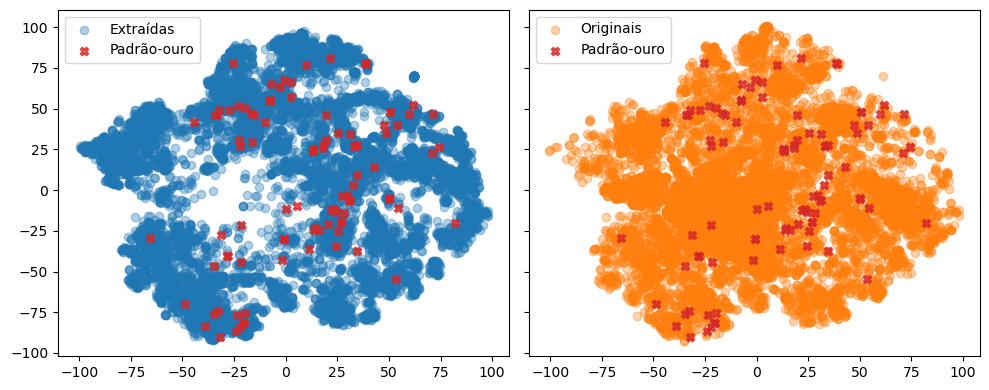

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)

panels = [
    (axes[0], extracted_2d, 'tab:blue', 'Extraídas'),
    (axes[1], originals_2d, 'tab:orange', 'Originais'),
]

for ax, points, color, label in panels:
    ax.scatter(points[:, 0], points[:, 1], alpha=0.35, color=color, label=label)
    ax.scatter(
        gold_2d[:, 0],
        gold_2d[:, 1],
        alpha=0.8,
        marker='X',
        color='tab:red',
        label='Padrão-ouro',
    )
    ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH_FIGS, f'tsne_side_by_side_{MODEL_NAME}.png'))
plt.show()

In [25]:
fig = make_subplots(
    rows=1,
    cols=2,
    shared_xaxes=True,
    shared_yaxes=True,
    subplot_titles=('Extraídas e padrão-ouro', 'Originais e padrão-ouro'),
)

fig.add_trace(go.Scattergl(
    x=extracted_2d[:, 0],
    y=extracted_2d[:, 1],
    mode='markers',
    name='Extraídas',
    text=extracted_questions,
    marker=dict(color='#1f77b4', opacity=0.5, size=6),
    hovertemplate='%{text}<extra>Pergunta extraída</extra>'
), row=1, col=1)

fig.add_trace(go.Scattergl(
    x=originals_2d[:, 0],
    y=originals_2d[:, 1],
    mode='markers',
    name='Originais',
    text=original_comments,
    marker=dict(color='#2ca02c', opacity=0.25, size=6),
    hovertemplate='%{text}<extra>Comentário original</extra>'
), row=1, col=2)

fig.add_trace(go.Scattergl(
    x=gold_2d[:, 0],
    y=gold_2d[:, 1],
    mode='markers',
    name='Padrão-ouro',
    text=gold_questions,
    marker=dict(color='#d62728', opacity=0.8, size=9, symbol='x'),
    hovertemplate='%{text}<extra>Pergunta padrão-ouro</extra>',
    legendgroup='gold',
), row=1, col=1)

fig.add_trace(go.Scattergl(
    x=gold_2d[:, 0],
    y=gold_2d[:, 1],
    mode='markers',
    name='Padrão-ouro',
    text=gold_questions,
    marker=dict(color='#d62728', opacity=0.8, size=9, symbol='x'),
    hovertemplate='%{text}<extra>Pergunta padrão-ouro</extra>',
    legendgroup='gold',
    showlegend=False,
), row=1, col=2)

fig.update_layout(
    width=1000,
    height=400,
    margin=dict(l=20, r=20, t=50, b=20),
    xaxis_title=None,
    yaxis_title=None,
    template='plotly_white',
)
fig.update_xaxes(matches='x')
fig.update_yaxes(matches='y')

fig.write_html(
    os.path.join(OUTPUT_PATH_FIGS, f'tsne_side_by_side_{MODEL_NAME}.html')
)
fig.show()

In [26]:
# Alinha cada pergunta extraída ao comentário do qual ela foi extraída.
df_pairs = df_extracted.merge(
    df_originals,
    on='comment_id',
    how='left',
    validate='many_to_one',
)

assert len(df_pairs) == len(df_extracted)
assert df_pairs['comment'].notna().all()

In [ ]:
original_embedding_by_id = dict(zip(original_comment_ids, originals))
paired_comment_embeddings = np.vstack(
    df_pairs['comment_id']
    .map(original_embedding_by_id)
    .to_list()
)
question_embeddings = extracted

assert question_embeddings.shape == paired_comment_embeddings.shape

In [28]:
# Como os embeddings já estão normalizados, o produto escalar é o cosseno.
df_pairs['similaridade_pergunta_comentario'] = np.sum(
    question_embeddings * paired_comment_embeddings,
    axis=1,
)

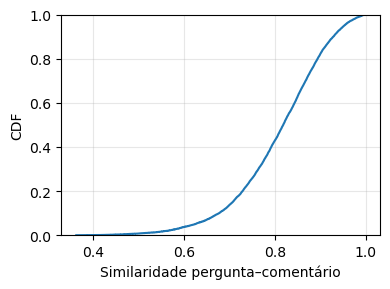

In [29]:
plt.figure(figsize=(4, 3))
sns.ecdfplot(data=df_pairs, x='similaridade_pergunta_comentario')
plt.ylabel('CDF')
plt.xlabel('Similaridade pergunta–comentário')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH_FIGS, f'{cache_prefix}_question_comment_similarity_ecdf.png'))
plt.show()

In [30]:
pair_columns = [
    'comment_id', 'perguntas', 'comment',
    'similaridade_pergunta_comentario', 'topic_id', 'Name',
]

In [31]:
# Pares menos semelhantes: úteis para inspecionar extrações possivelmente ruins.
df_pairs.nsmallest(3, 'similaridade_pergunta_comentario')[pair_columns]

,comment_id,perguntas,comment,similaridade_pergunta_comentario,topic_id,Name
5261,UgztapnEFKl0IcNXgU94AaABAg.ANWhAUn1n9sANdfEQc5q4r,Quem trabalha e vai entrar em licença-maternidade também tem direito ao auxílio-maternidade?,Msm coisa eu Vc soube se tem?,0.361800,1,1_maternidade_auxílio_direito_solicitar
5504,UgzB19T0mLyJv40XCaZ4AaABAg.AKvKiTyKsRNALVesBsS9va,Quantos dias após tomar a pílula do dia seguinte é considerado normal para a próxima menstruação?,Também queria saber 😢,0.363539,5,5_anticoncepcional_pílula_tomar_dia seguinte
8295,UgzxmOn2mDwzQ8Luc3N4AaABAg.AKZ4G5Txb-eAWROyPXAwNb,Por que não se deve tomar essa vacina se ela for de RNA mensageiro na gravidez?,Como assim? Pode nos falar mais sobrenome?,0.368734,29,29_vacina_contra_tomar_aplicada


In [32]:
# Pares mais semelhantes servem como verificação positiva do alinhamento.
df_pairs.nlargest(3, 'similaridade_pergunta_comentario')[pair_columns]

,comment_id,perguntas,comment,similaridade_pergunta_comentario,topic_id,Name
1768,UgyUTGuV5ddA_TgLBNh4AaABAg,Quem tem nódulo benigno na mama e no fígado pode usar hormônios?,Quem tem nódulo benigno na mama e no fígado pode usar hormônios?,1.0,4,4_progesterona_via_reposição_vaginal
2952,UgyEqmmqpjG8HWhTk1h4AaABAg,Coceira nos seios pode ser um sintoma de gravidez?,Coceira nos seios pode ser um sintoma de gravidez?,1.0,9,9_sentir_normal sentir_gravidez normal_dor
11151,UgxZ7Qlxu6nmlBR0oSV4AaABAg,Qual é a mamadeira da moda?,Qual é a mamadeira da moda?,1.0,0,0_leite_materno_peito_amamentação


In [33]:
similarity_by_topic = (
    df_pairs
    .groupby(['topic_id', 'Name'], dropna=False)['similaridade_pergunta_comentario']
    .agg(['count', 'mean', 'median', 'std'])
    .sort_values('mean')
)
similarity_by_topic.head()

,,count,mean,median,std
topic_id,Name,,,,
26,26_diu_sexual_relação sexual_durante relação,161,0.767573,0.787404,0.114333
8,8_teste_teste gravidez_positivo_resultado,347,0.768920,0.771822,0.091129
2,2_parto_parto normal_pós parto_durante parto,817,0.783780,0.792931,0.109579
25,25_placenta_retirada_anestesia_mão,163,0.788271,0.803792,0.113501
15,15_ultrassom_ultrassonografia_pré natal_natal,260,0.794514,0.796516,0.097949


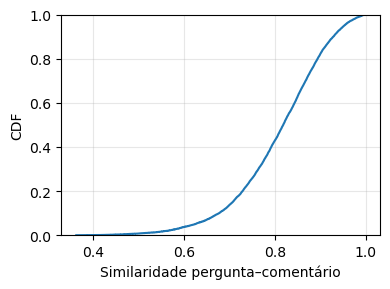

In [34]:
plt.figure(figsize=(4, 3))
sns.ecdfplot(
    data=df_pairs,
    x='similaridade_pergunta_comentario',
)

plt.ylabel('CDF')
plt.xlabel('Similaridade pergunta–comentário')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()